In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [19]:
path = "/pfs/10/work/hd_cu284-work/fargo3d/outputs/fargo_fiducial/"
paths = [path]

In [20]:

max_n =100
rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in range(max_n+1):
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

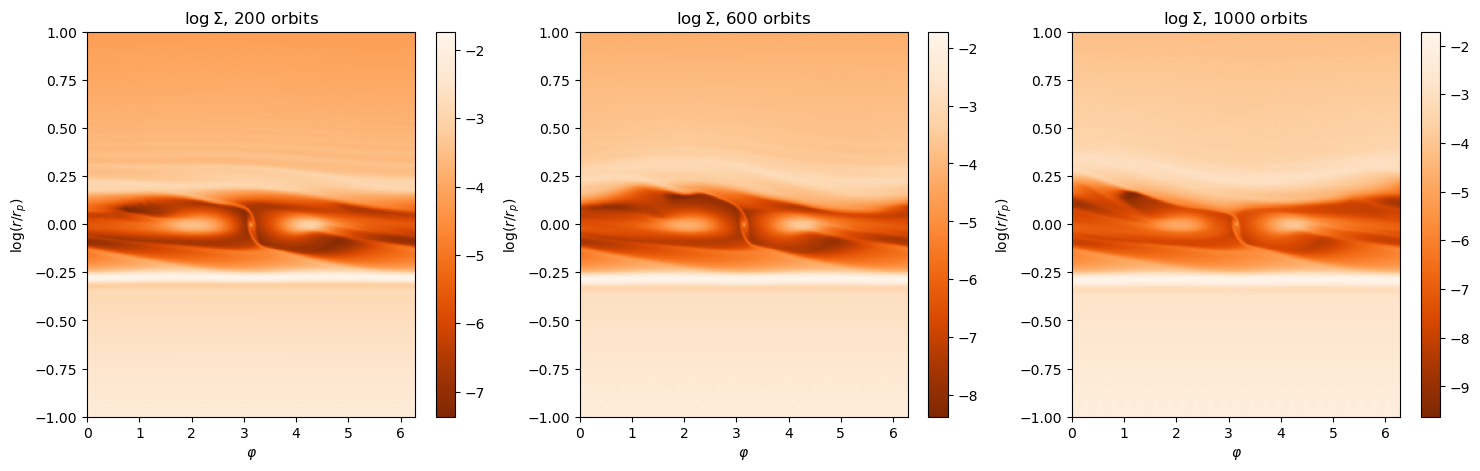

In [29]:
%matplotlib inline

frames = [20,60,100]
plt.figure(figsize=(len(frames)*6,5))
R_min = 0.1      
R_max = 10

for i,frame in enumerate(frames):
    plt.subplot(1,len(frames),1+i)
    plt.imshow(np.log10(rho_cube[0][frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(R_min),np.log10(R_max)])
    plt.title(f"$\\log \\Sigma$, {frame*10} orbits")
    plt.colorbar()
    plt.xlabel("$\\varphi$")
    plt.ylabel("$\\log(r/r_p)$")


In [22]:
R_min = 0.1      
R_max = 10
Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}domain_y.dat", sep="\n")[3:-4]#R_min * (R_max / R_min)**(np.linspace(0, 1, Nr))
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, phi, indexing='ij')

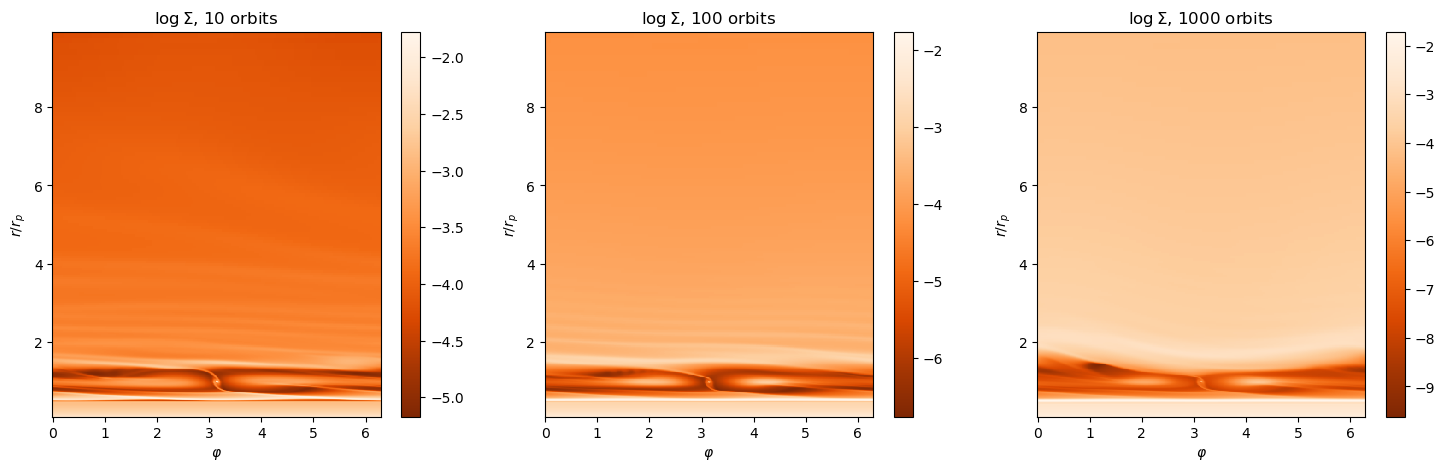

In [23]:
%matplotlib inline

frames = [1,10,100]
plt.figure(figsize=(len(frames)*6,5))


for i,frame in enumerate(frames):
    plt.subplot(1,len(frames),1+i)
    
    plt.pcolormesh(PHI, R, np.log10(rho_cube[0][frame]),cmap=cm.Oranges_r, shading='auto')
    plt.xlabel("$\\varphi$")
    plt.ylabel("$r/r_p$")
    plt.title(f"$\\log \\Sigma$, {frame*10} orbits")
    plt.colorbar()


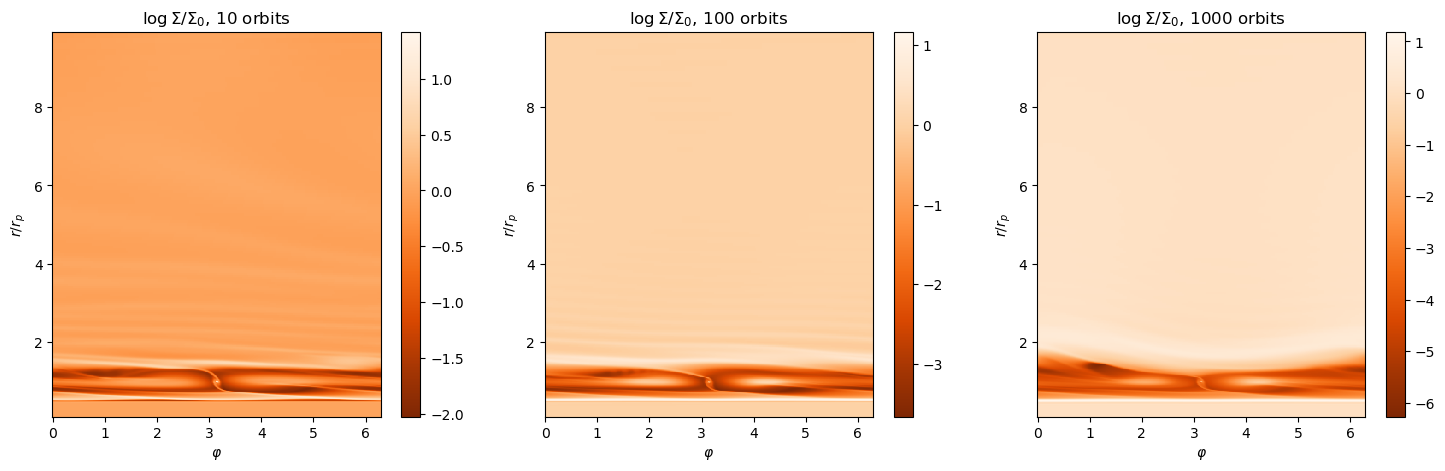

In [24]:
%matplotlib inline

frames = [1,10,100]
plt.figure(figsize=(len(frames)*6,5))


for i,frame in enumerate(frames):
    plt.subplot(1,len(frames),1+i)
    
    plt.pcolormesh(PHI, R, np.log10(rho_cube[0][frame]/rho_cube[0][0]),cmap=cm.Oranges_r, shading='auto')
    plt.xlabel("$\\varphi$")
    plt.ylabel("$r/r_p$")
    plt.title(f"$\\log \\Sigma/\\Sigma_0$, {frame*10} orbits")
    plt.colorbar()
